# 0. OUTRIDER comparison -- coverage, CV calibration, and PPC vs OUTRIDER, same HC cohort/splits.

In [38]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

import json

OC = config.OUTRIDER_COMPARISON_DIR
pd.set_option("display.width", 120)


## 1. Gene coverage by expression stratum

In [45]:
cov = pd.read_csv(OC / "gene_coverage_by_expression.csv", index_col=0)
cov["nz_bin"] = pd.Categorical(cov["nz_bin"],
    categories=["1-10", "11-30(pool)", "31-100", "101-300", "301-676(near-universal)"], ordered=True)

tab1 = cov.groupby("nz_bin", observed=True).agg(
    n_genes=("nz", "size"),
    our_engine_modeled_frac=("engine_ok", "mean"),
    outrider_fpkm_pass_frac=("outrider_pass", "mean"),
).round(3)
print("Coverage by detection-frequency stratum (fraction of genes each engine can model):")
tab1

Coverage by detection-frequency stratum (fraction of genes each engine can model):


,n_genes,our_engine_modeled_frac,outrider_fpkm_pass_frac
nz_bin,,,
1-10,873,1.0,0.000
11-30(pool),1227,1.0,0.000
31-100,2206,1.0,0.013
101-300,2972,1.0,0.201
301-676(near-universal),12580,1.0,0.947


## 2. Gene coverage including both engines' own modeling failures

In [48]:
training_summary = pd.read_csv(config.ENGINE_MIXED_DIR / "training_summary.csv")
n_universe_ours = len(training_summary)
n_ok_ours = int(training_summary["ok"].sum())
n_excluded_ours = n_universe_ours - n_ok_ours

fold_stats = pd.read_csv(config.CV_MIXED_DIR / "fold_stats.csv")
per_gene_fold = fold_stats.groupby("gene")["ok"].agg(["sum", "count"])
n_stable_all_folds = int((per_gene_fold["sum"] == per_gene_fold["count"]).sum())
n_any_fold_fail = int((per_gene_fold["sum"] < per_gene_fold["count"]).sum())
n_model_route = len(per_gene_fold)

outrider_summary = json.load(open(OC / "outrider_coverage_summary.json"))
n_universe_outr = outrider_summary["universe_genes"]
n_fpkm_pass = outrider_summary["fpkm_filter_pass"]
n_fit_dropped = outrider_summary["n_nb_fit_dropped"]
n_final_outr = outrider_summary["final_modeled_genes_actual"]

coverage_table = pd.DataFrame([
    ["universe attempted", f"{n_universe_ours:,} (all protein-coding)", f"{n_universe_outr:,} (our engine's own successful set)"],
    ["upstream filter pass", "--", f"{n_fpkm_pass:,} ({n_fpkm_pass/n_universe_outr:.1%}, FPKM>=1)"],
    ["fit failures", f"{n_excluded_ours:,} ({n_excluded_ours/n_universe_ours:.1%}, cascade excluded)", f"{n_fit_dropped:,} (NB optimizer, identical every CV fold)"],
    ["CV-fold stable (model route)", f"{n_stable_all_folds:,}/{n_model_route:,} ({n_stable_all_folds/n_model_route:.1%})", "--"],
    ["CV-fold failing >=1 (model route)", f"{n_any_fold_fail:,}/{n_model_route:,} ({n_any_fold_fail/n_model_route:.1%})", "--"],
    ["final modeled genes", f"{n_ok_ours:,} ({n_ok_ours/n_universe_ours:.1%})", f"{n_final_outr:,} ({n_final_outr/n_universe_outr:.1%})"],
], columns=["metric", "our engine", "OUTRIDER"]).set_index("metric")
coverage_table.to_clipboard(excel=True)


## 3. CV-level Z-score moments (held-out HC, pooled across 5 folds)

In [41]:
eng_cv = pd.read_csv(config.CV_MIXED_DIR / "cv_stats.csv").set_index("gene")
outr_cv = pd.read_csv(OC / "outrider_cv_metrics.csv").set_index("gene")
common_genes = eng_cv.index.intersection(outr_cv.index)
print(f"OUTRIDER-fittable genes: {len(outr_cv)}, of which also in our engine CV set: {len(common_genes)}")

with open(config.CV_MIXED_DIR / "cv_zscores_shash.pkl", "rb") as f:
    shash_z = pickle.load(f)
shash_mean = pd.Series({g: np.nanmean(v) for g, v in shash_z.items()})
shash_std = pd.Series({g: np.nanstd(v) for g, v in shash_z.items()})

eng_full = eng_cv[["mean_z", "std_z", "cv_raw_skew", "cv_raw_kurtosis", "cv_corrected_skew",
                    "cv_corrected_kurtosis", "cv_naive_exceed", "cv_shash_exceed"]].median()
eng_sub = eng_cv.loc[common_genes, ["mean_z", "std_z", "cv_raw_skew", "cv_raw_kurtosis", "cv_naive_exceed"]].median()
outr_med = outr_cv[["mean_z", "std_z", "skew_z", "kurt_z", "naive_exceed"]].median()

zmoments = pd.DataFrame({
    "our_engine_raw (full 19858g)": eng_full.reindex(["mean_z","std_z","cv_raw_skew","cv_raw_kurtosis","cv_naive_exceed"]).values,
    "our_engine_shash (full 19858g)": [shash_mean.median(), shash_std.median(), eng_full["cv_corrected_skew"], eng_full["cv_corrected_kurtosis"], eng_full["cv_shash_exceed"]],
    "our_engine_raw (12305g subset)": eng_sub.values,
    "outrider_raw (12305g)": outr_med.values,
}, index=["mean(Z)", "std(Z)", "skew(Z)", "kurtosis(Z)", "naive_exceed |Z|>1.96"])
zmoments


OUTRIDER-fittable genes: 12305, of which also in our engine CV set: 12305


,our_engine_raw (full 19858g),our_engine_shash (full 19858g),our_engine_raw (12305g subset),outrider_raw (12305g)
mean(Z),0.004820,0.000131,0.001704,-0.000014
std(Z),1.020272,1.032415,1.038666,0.999299
skew(Z),-0.039944,0.095009,-0.230245,-2.029905
kurtosis(Z),0.528247,0.416770,0.559581,6.853901
naive_exceed |Z|>1.96,0.051775,0.053254,0.057692,0.050296


## 4. CV posterior predictive check (PPC): obs vs model-implied mean/std/zero-fraction

In [42]:
eng_ppc = pd.read_csv(config.CV_MIXED_DIR / "cv_calibration_moments.csv").set_index("gene")
outr_ppc = pd.read_csv(OC / "outrider_cv_calibration_moments.csv").set_index("gene")

common_ppc_genes = eng_ppc.index.intersection(outr_ppc.index)
print(f"our engine PPC genes: {len(eng_ppc)} | OUTRIDER PPC genes: {len(outr_ppc)} | common: {len(common_ppc_genes)}")

eng_ppc_full = eng_ppc.median()
eng_ppc_sub = eng_ppc.loc[common_ppc_genes].median()
outr_ppc_med = outr_ppc.median()
ppc_table = pd.DataFrame({
    "our_engine (full 19858g)": eng_ppc_full.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "our_engine (12305g subset)": eng_ppc_sub.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "outrider (12305g)": outr_ppc_med.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
}, index=["mean (obs)", "mean (pred)", "std (obs)", "std (pred)", "zero-frac (obs)", "zero-frac (pred)"])
ppc_table


our engine PPC genes: 19858 | OUTRIDER PPC genes: 12305 | common: 12305


,our_engine (full 19858g),our_engine (12305g subset),outrider (12305g)
mean (obs),28.432692,106.890533,106.890533
mean (pred),29.164234,108.640407,113.467825
std (obs),67.865777,172.779542,172.779542
std (pred),95.376236,213.411176,214.177338
zero-frac (obs),0.239645,0.059172,0.059172
zero-frac (pred),0.208794,0.037367,0.022463


### 4a. Gene-level calibration (Pearson r/R2/Spearman rho/RMSE/MAE) and PPC scatter, especially variance

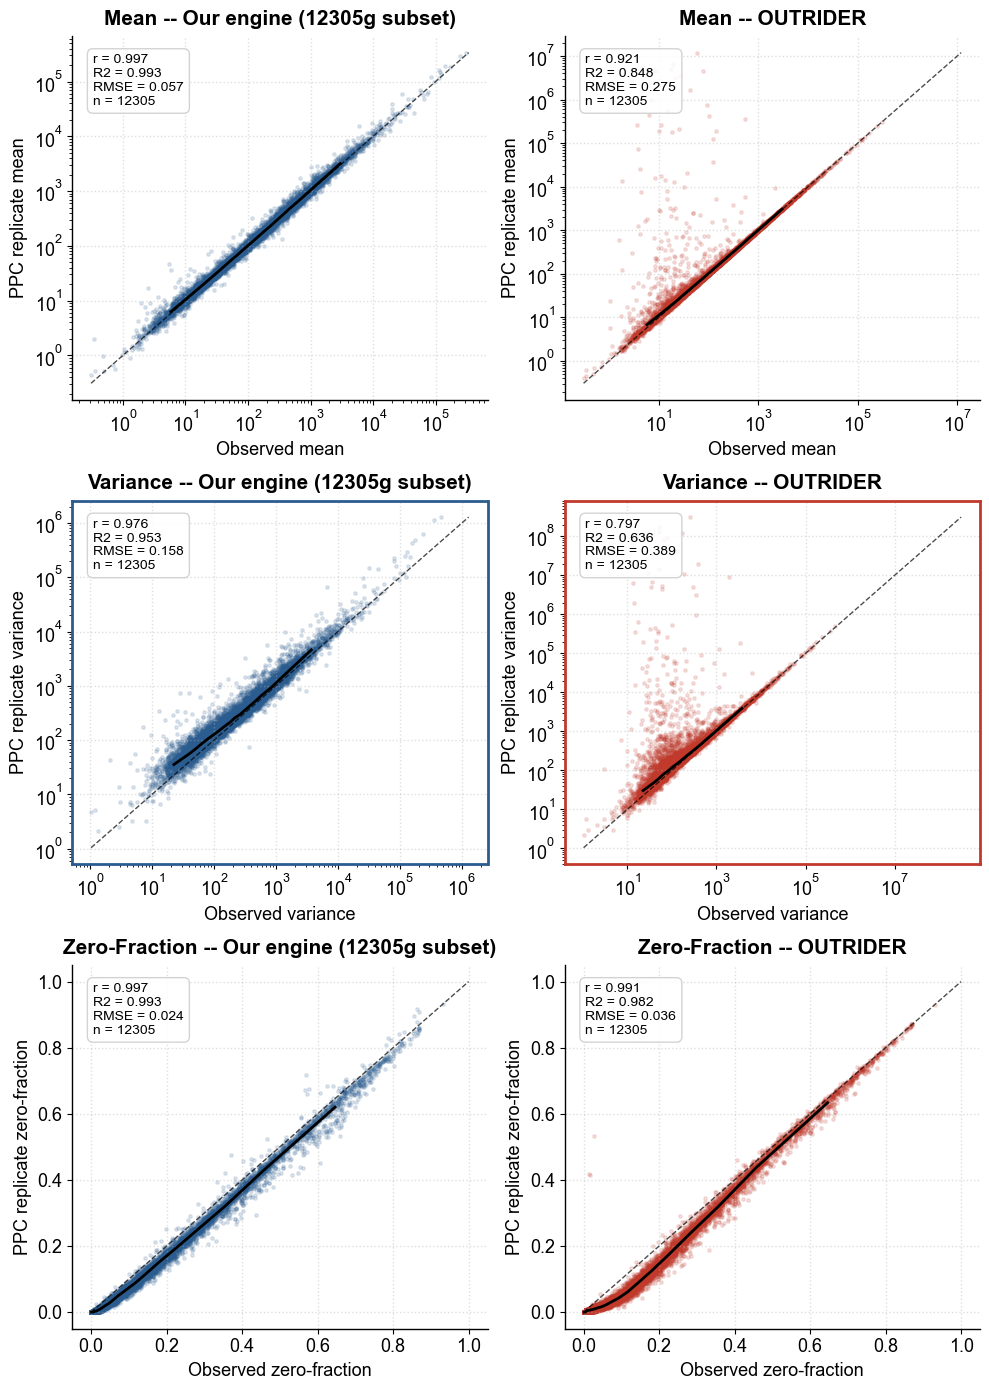

In [43]:
from scipy.stats import pearsonr

def calib_stats_(o, p, logscale):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p)
    o, p = o[m], p[m]
    if logscale:
        o, p = np.log10(o + 1), np.log10(p + 1)
    r, _ = pearsonr(o, p)
    return r, r ** 2, np.sqrt(np.mean((p - o) ** 2)), len(o)

def binned_(o, p, nb_=20):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p) & (o > 0)
    o, p = o[m], p[m]
    q = np.unique(np.quantile(o, np.linspace(0, 1, nb_ + 1)))
    idx = np.clip(np.digitize(o, q[1:-1]), 0, len(q) - 2)
    return (np.array([np.median(o[idx == k]) for k in range(len(q) - 1)]),
            np.array([np.median(p[idx == k]) for k in range(len(q) - 1)]))

eng_sub_cal = pd.read_csv(OC / "our_engine_cv_calibration_moments_12305subset.csv")
outr_cal = pd.read_csv(OC / "outrider_cv_calibration_moments.csv")

panels = [("obs_mean", "pred_mean", "Mean", True), ("obs_var", "pred_var", "Variance", True),
         ("obs_zero", "pred_zero", "Zero-Fraction", False)]
engines = [("Our engine (12305g subset)", eng_sub_cal, "#2b5c8f"), ("OUTRIDER", outr_cal, "#c0392b")]

fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for row, (oc, pc, title_str, logsc) in enumerate(panels):
    xlim = None
    for col, (eng_label, cal, color) in enumerate(engines):
        ax = axes[row, col]
        ax.scatter(cal[oc], cal[pc], s=6, alpha=0.15, color=color)
        bx, by = binned_(cal[oc], cal[pc])
        ax.plot(bx, by, '-', color='black', linewidth=2)

        if logsc:
            lo = max(min(cal[oc].min(), cal[pc].min()), 1e-3)
            hi = max(cal[oc].max(), cal[pc].max())
            ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.7)
            ax.set_xscale('log'); ax.set_yscale('log')
        else:
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)

        r, r2, rmse, n = calib_stats_(cal[oc], cal[pc], logsc)
        ax.set_title(f"{title_str} -- {eng_label}", fontweight='bold', pad=8)
        ax.set_xlabel(f'Observed {title_str.lower()}')
        ax.set_ylabel(f'PPC replicate {title_str.lower()}')
        stats_text = f"r = {r:.3f}\nR2 = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {n}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4)
        if row == 1:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('#c0392b' if col == 1 else '#2b5c8f')
                spine.set_linewidth(2)

plt.tight_layout()
fig.savefig(OC / 'Figures' / 'ppc_scatter_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [44]:
calib = pd.read_csv(OC / "ppc_calib_stats.csv")
calib_wide = calib.pivot(index="panel", columns="engine",
                         values=["pearson_r", "r2", "spearman_rho", "rmse", "mae"])
calib_wide = calib_wide.reindex(["mean", "var", "zero_frac"])
calib_wide = calib_wide.reindex(columns=["our_engine_full19858", "our_engine_12305subset", "outrider_12305"], level=1)
calib_wide

pearson_r                                                         r2                         \
engine    our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset   
panel                                                                                                              
mean                  0.994724               0.996668       0.920928             0.989476               0.993347   
var                   0.968040               0.976067       0.797423             0.937101               0.952707   
zero_frac             0.999204               0.996640       0.990963             0.998408               0.993290   

                                 spearman_rho                                                       rmse  \
engine    outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858   
panel                                                                                                      
mean            0.848109             0.994357               0.997296       0.968982             0.106802   
var             0.635883             0.972872               0.975402       0.912078             0.257652   
zero_frac       0.982008             0.998285               0.994491       0.987853             0.020782   

                                                                 mae                                        
engine    our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305  
panel                                                                                                       
mean                    0.056810       0.274961             0.047371               0.036443       0.045216  
var                     0.157936       0.389463             0.154947               0.115384       0.118162  
zero_frac               0.024257       0.035696             0.015655               0.019473       0.027574

## Notes: coverage/PPC use the corrected FPKM>=1 filter + NB-fit retry-drop; variance R2 gap visible gene-by-gene above.